In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [10]:
df = pd.read_csv("../data/feat/go_emotions_with_features.csv")

df.columns.tolist()

['UNCLEAN_TEXT_PT',
 'BASE_TEXT_PT',
 'admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise',
 'neutral',
 'id',
 'text',
 'UNCLEAN_TEXT_EN',
 'BASE_TEXT_EN',
 'doc',
 'n_words',
 'n_sentences',
 'words_per_sentence',
 'n_characters',
 'reading_time',
 'uppercase_ratio',
 'char_repetition_ratio',
 'avg_letters_per_word',
 'avg_syllables_per_word',
 'total_punct',
 'punct_per_word',
 'punct_per_sentence',
 'exclam',
 'quest',
 'rarest_word',
 'most_common_word',
 'avg_freq',
 'freq_disp',
 'ttr',
 'stopword_ratio',
 'n_unique_words',
 'mean_unique_word_length',
 'flesch_portuguese',
 'NOUN',
 'VERB',
 'ADJ',
 'ADV',
 'PRON',
 'DET',
 'ADP',
 'AUX',
 'CCONJ',
 'SCONJ',
 'NUM',
 'PROPN',
 'INTJ',
 'mea

In [14]:
features = [
    'n_words', 'n_sentences', 'words_per_sentence',
    'avg_letters_per_word', 'avg_syllables_per_word',
    'ttr', 'stopword_ratio', 'flesch_portuguese',
    'mean_dependency_length', 'lexical_entropy'
]

desc = df[features].describe()
desc

,n_words,n_sentences,words_per_sentence,avg_letters_per_word,avg_syllables_per_word,ttr,stopword_ratio,flesch_portuguese,mean_dependency_length,lexical_entropy
count,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000
mean,15.310267,1.665966,10.233970,4.580766,1.891157,0.956276,0.558244,80.037545,2.345320,2.271324
std,7.972206,0.903108,5.927295,1.133827,0.543619,0.070319,0.159414,39.420406,0.656078,0.627128
min,1.000000,1.000000,1.000000,1.200000,1.000000,0.000000,0.000000,-4095.040000,0.000000,0.000000
25%,9.000000,1.000000,6.000000,4.034483,1.666667,0.923077,0.500000,67.440000,1.909091,1.945910
50%,15.000000,1.000000,9.000000,4.500000,1.850000,1.000000,0.571429,81.365714,2.333333,2.397895
75%,21.000000,2.000000,13.000000,5.000000,2.000000,1.000000,0.666667,95.840000,2.750000,2.751667
max,351.000000,74.000000,46.000000,111.000000,60.000000,1.000000,1.000000,153.913333,14.054054,3.472415


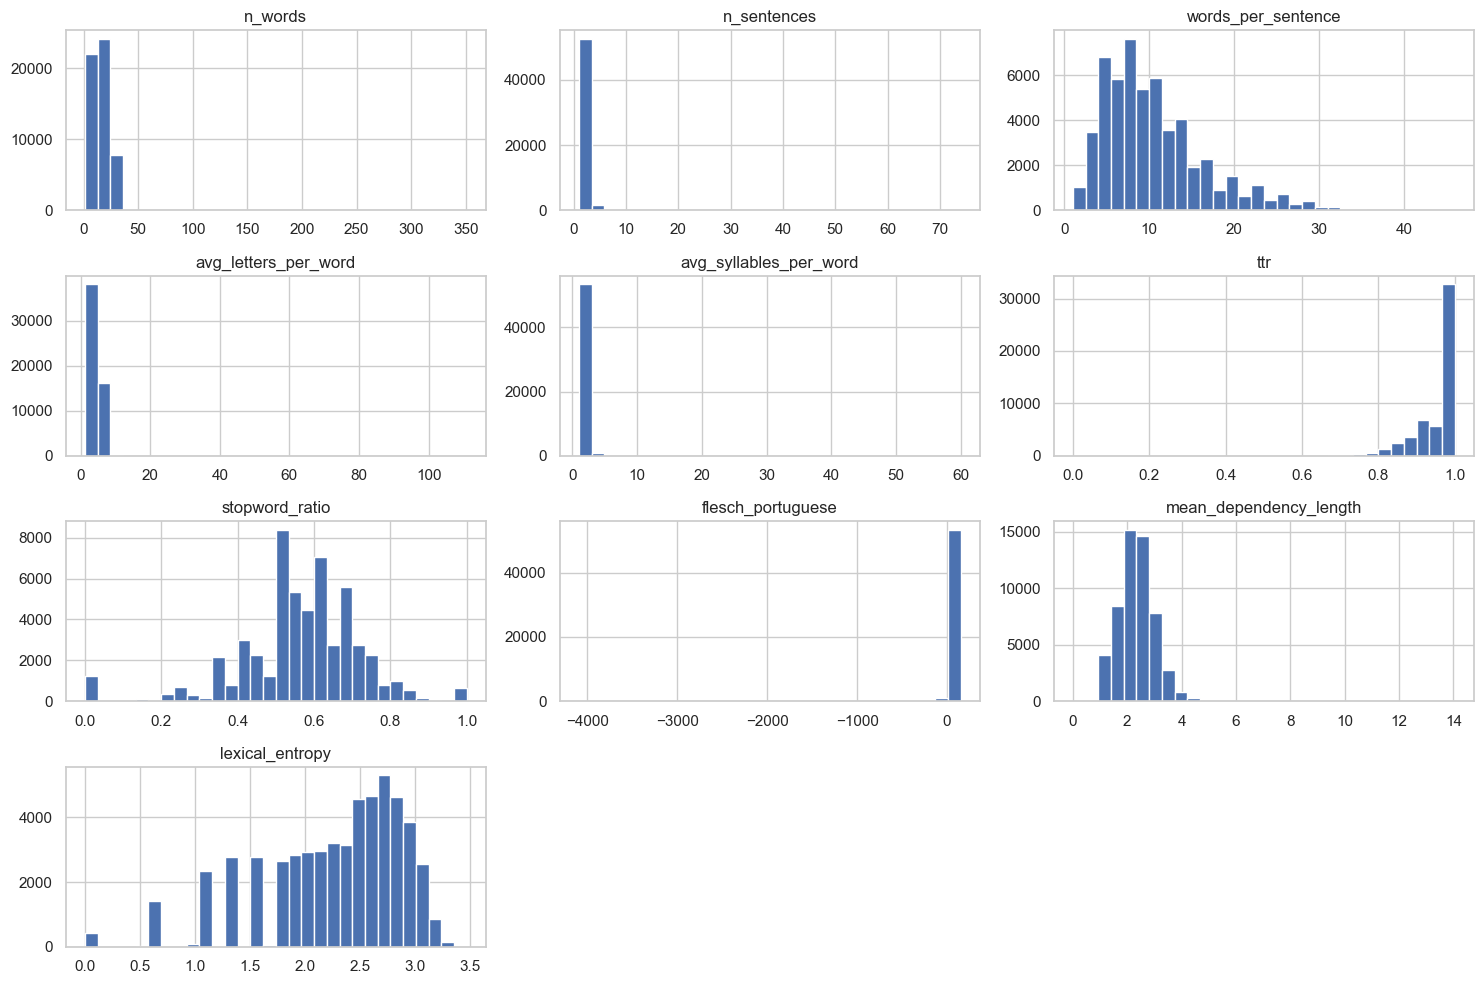

In [15]:
df[features].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

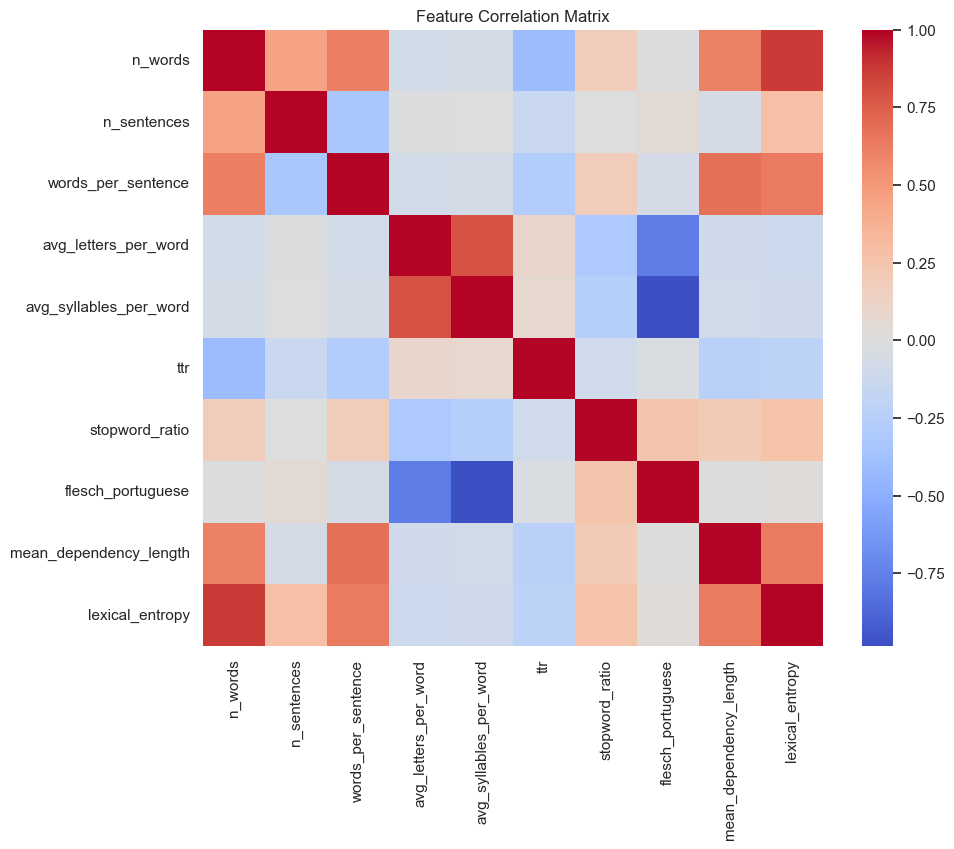

In [16]:
corr = df[features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [17]:
emotion_cols = [
    'admiration','amusement','anger','annoyance','approval',
    'caring','confusion','curiosity','desire','disappointment',
    'disapproval','disgust','embarrassment','excitement','fear',
    'gratitude','grief','joy','love','nervousness','optimism',
    'pride','realization','relief','remorse','sadness','surprise','neutral'
]

df_long = df.melt(
    id_vars=features,
    value_vars=emotion_cols,
    var_name='emotion',
    value_name='label'
)

df_long = df_long[df_long['label'] == 1]

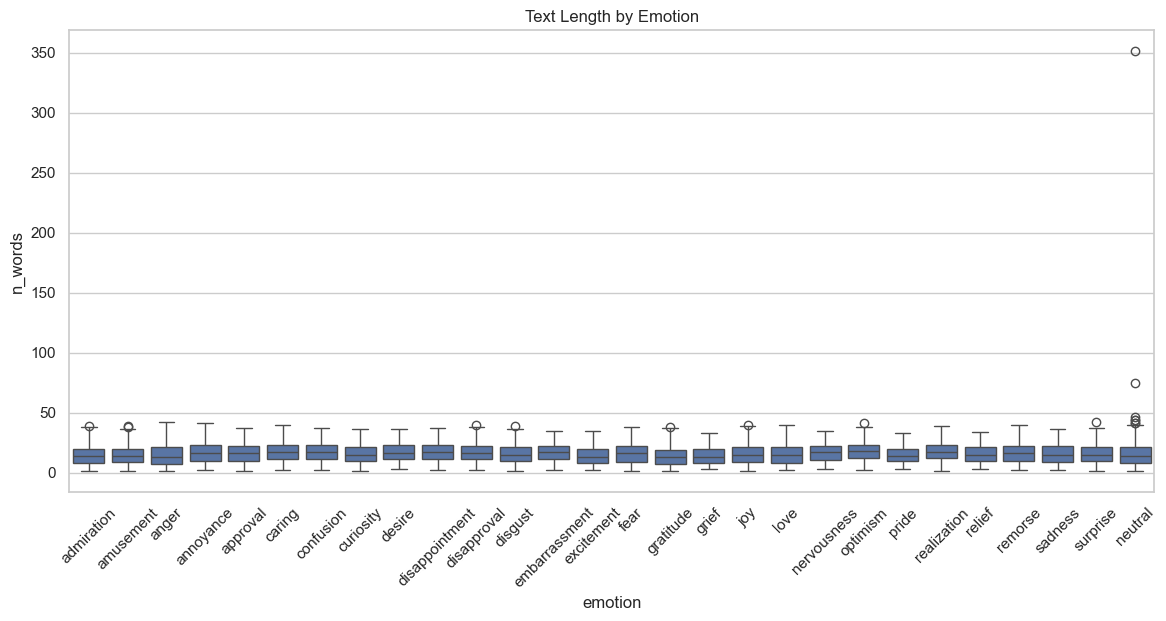

In [18]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df_long, x='emotion', y='n_words')
plt.xticks(rotation=45)
plt.title("Text Length by Emotion")
plt.show()

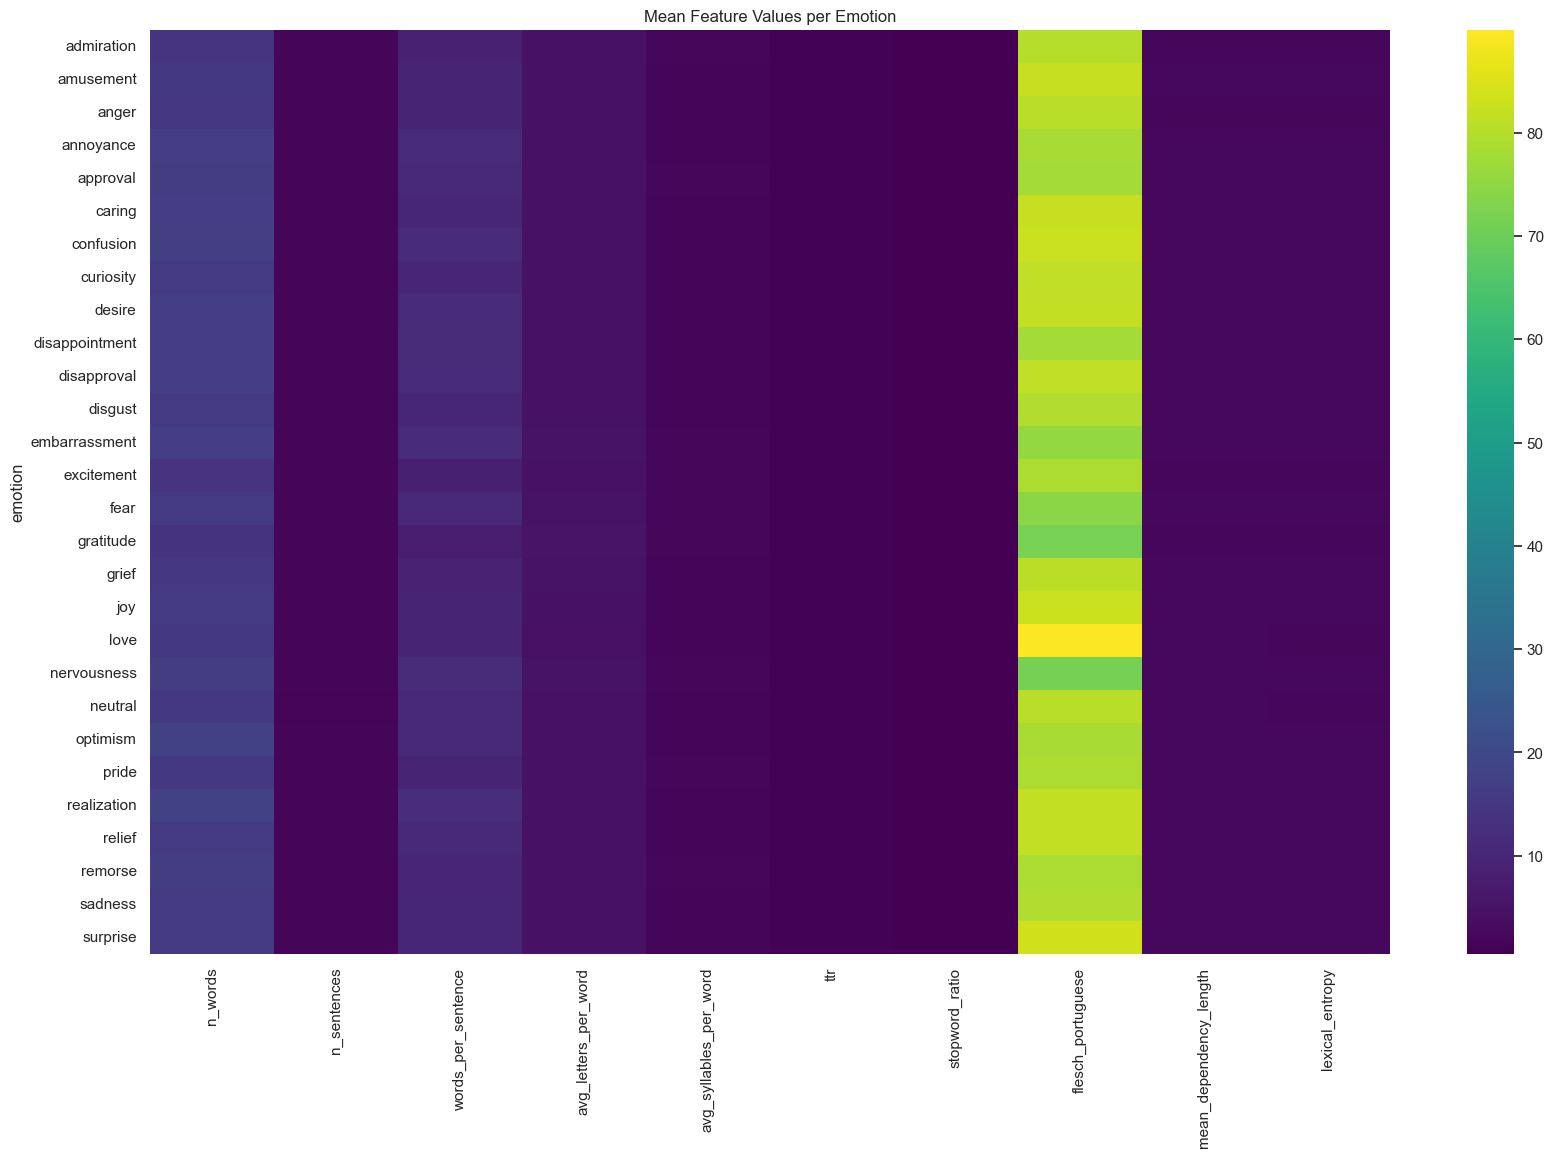

In [20]:
emotion_means = df_long.groupby('emotion')[features].mean()

plt.figure(figsize=(20,12))
sns.heatmap(emotion_means, cmap="viridis")
plt.title("Mean Feature Values per Emotion")
plt.show()

In [21]:
from scipy.stats import f_oneway

results = {}

for feature in features:
    groups = [
        df[df[emotion] == 1][feature].dropna()
        for emotion in emotion_cols
    ]
    
    f, p = f_oneway(*groups)
    results[feature] = p

anova_df = pd.DataFrame.from_dict(results, orient='index', columns=['p_value'])
anova_df.sort_values('p_value', inplace=True)

print(anova_df)

                              p_value
words_per_sentence       0.000000e+00
stopword_ratio           0.000000e+00
lexical_entropy          0.000000e+00
n_words                 5.336823e-223
avg_letters_per_word    1.227197e-208
mean_dependency_length  3.151396e-208
n_sentences             6.071544e-184
ttr                     1.296108e-125
avg_syllables_per_word  4.086411e-106
flesch_portuguese        2.100524e-82


In [22]:
top_features = emotion_means.std().sort_values(ascending=False).head(10)

print(top_features)

flesch_portuguese         3.674786
n_words                   1.105286
words_per_sentence        1.048713
avg_letters_per_word      0.137302
lexical_entropy           0.105261
mean_dependency_length    0.090051
n_sentences               0.085425
avg_syllables_per_word    0.052302
stopword_ratio            0.028561
ttr                       0.007128
dtype: float64
